# Inicio rápido: la Encuesta Intercensal 2025 en un DataFrame

Un solo `pd.read_csv` y tienes todos los datos: una fila por lugar (país, entidades, municipios y localidades de 50 000 o más habitantes) y una columna por indicador.

In [1]:
import pandas as pd

df = pd.read_csv("https://eic.datzin.com.mx/api/descargas/eic2025.csv")
df.shape

(2776, 346)

In [2]:
df.head()

,cvegeo,nivel,entidad,municipio,lugar,INDICE_ENV,INDICE_ENV_F,INDICE_ENV_M,MEDIANA_F,MEDIANA_M,...,PCN_VPH_TINACO,PCN_VPH_TLOSA,PCN_VPH_TOTRO,PCN_VPH_TV,PCN_VPH_TVP,PCN_VPH_VENDER,PROM_OCUP,PRO_OCUP_C,VIVPARHAB,VIVPARHAB_C
0,0,nacional,Estados Unidos Mexicanos,Total nacional,Estados Unidos Mexicanos,68.22,75.60,61.02,32.85,30.91,...,70.61,81.14,3.34,89.49,35.91,53.30,3.29,0.90,39699242.0,39636594.0
1,10000000,entidad,Aguascalientes,Total de la entidad,Aguascalientes,55.17,60.97,49.47,30.89,28.76,...,77.95,98.12,0.16,95.84,40.18,53.28,3.42,0.82,449177.0,448471.0
2,10010000,municipio,Aguascalientes,Aguascalientes,Aguascalientes,63.04,70.35,55.75,32.08,29.62,...,74.77,99.35,0.12,96.47,46.68,54.31,3.31,0.78,309587.0,309028.0
3,10010001,localidad,Aguascalientes,Aguascalientes,Aguascalientes,65.66,73.74,57.58,32.51,29.79,...,74.30,99.78,0.09,96.64,48.65,54.35,3.27,0.76,283086.0,282557.0
4,10020000,municipio,Aguascalientes,Asientos,Asientos,38.78,39.85,37.72,26.45,24.85,...,89.76,85.07,0.31,93.00,14.24,54.40,3.73,0.99,14396.0,14391.0


## ¿Qué significa cada columna?

El diccionario trae el nombre y el tema de cada código.

In [3]:
indicadores = pd.read_csv("https://eic.datzin.com.mx/api/descargas/indicadores.csv")
indicadores[indicadores.nombre.str.contains("Internet")][["codigo", "nombre"]]

,codigo,nombre
304,PCN_VPH_INTER,Porcentaje de viviendas particulares habitadas...


## Entidades con más viviendas con internet

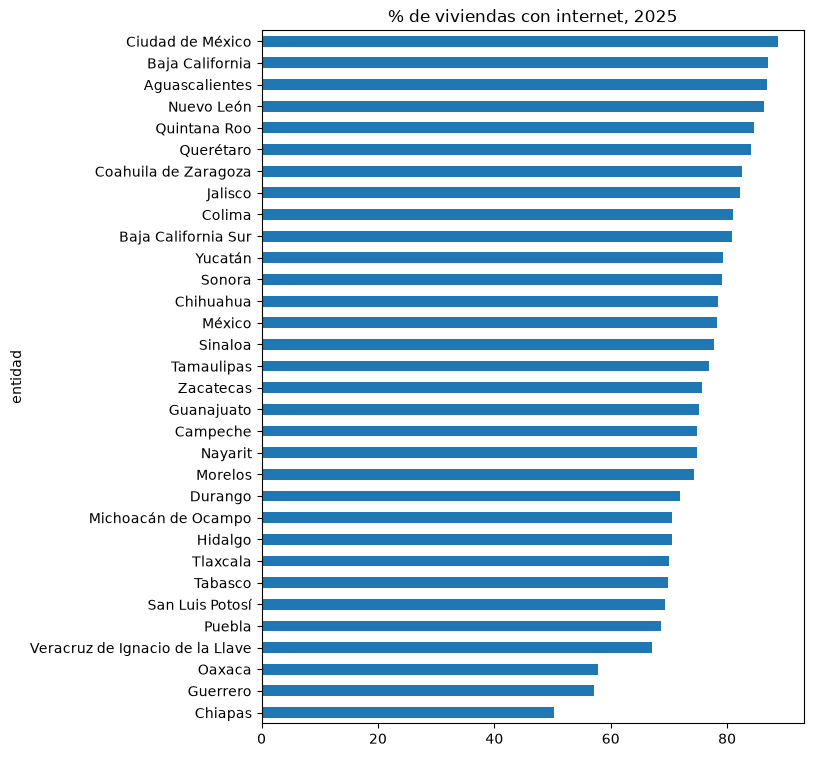

In [4]:
estados = df[df.nivel == "entidad"].set_index("entidad")
estados["PCN_VPH_INTER"].sort_values().plot.barh(figsize=(7, 9), title="% de viviendas con internet, 2025");

## Los municipios de Jalisco con más población sin afiliación a servicios de salud

In [5]:
jalisco = df[(df.nivel == "municipio") & (df.entidad == "Jalisco")]
jalisco.nlargest(10, "PCN_PSINDER")[["lugar", "PCN_PSINDER"]]

,lugar,PCN_PSINDER
712,Santa María del Oro,85.20
687,Degollado,64.24
771,Tuxcueca,63.72
779,Villa Guerrero,63.72
750,Teocaltiche,58.68
727,Quitupan,53.70
715,Mazamitla,53.18
669,Ayotlán,52.25
756,Tizapán el Alto,51.76
696,Huejúcar,48.35


## Varios indicadores a la vez

In [6]:
estados[["GRAPROES", "PCN_PSINDER", "PCN_HOG_ALIM_N", "PCN_VPH_INTER"]].corr().round(2)

,GRAPROES,PCN_PSINDER,PCN_HOG_ALIM_N,PCN_VPH_INTER
GRAPROES,1.00,-0.78,-0.39,0.90
PCN_PSINDER,-0.78,1.00,0.30,-0.74
PCN_HOG_ALIM_N,-0.39,0.30,1.00,-0.49
PCN_VPH_INTER,0.90,-0.74,-0.49,1.00


## ¿Qué tan confiable es cada cifra?

Son estimaciones por muestreo. El archivo completo trae una fila por lugar e indicador, con el error estándar, los límites de confianza al 90 % y la `precision` según INEGI: alta, moderada o baja.

In [7]:
completo = pd.read_csv("https://eic.datzin.com.mx/api/descargas/eic2025_completo.csv.gz")
completo.precision.value_counts()

precision
alta                               819155
moderada                            83889
baja                                40788
sin dato (muestra insuficiente)      1771
no aplica                            1013
Name: count, dtype: int64

In [8]:
# los mismos municipios de Jalisco, ahora con su precisión
completo[(completo.indicador == "PCN_PSINDER") & (completo.entidad == "Jalisco") & (completo.nivel == "municipio")]\
    .nlargest(10, "valor")[["lugar", "valor", "lim_inf", "lim_sup", "precision"]]

,lugar,valor,lim_inf,lim_sup,precision
242980,Santa María del Oro,85.20,85.20,85.20,alta
234455,Degollado,64.24,60.96,67.39,alta
263099,Tuxcueca,63.72,59.28,67.94,alta
265827,Villa Guerrero,63.72,58.70,68.47,alta
255938,Teocaltiche,58.68,55.95,61.35,alta
248095,Quitupan,53.70,46.60,60.64,alta
244003,Mazamitla,53.18,47.62,58.66,alta
228317,Ayotlán,52.25,48.12,56.34,alta
257984,Tizapán el Alto,51.76,48.20,55.29,alta
237524,Huejúcar,48.35,42.52,54.23,alta


---
*Fuente: INEGI, Encuesta Intercensal. Datos: [EIC API + MCP](https://github.com/zamax14/EIC-API-MCP).*